In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split


In [2]:
df=pd.read_csv("playtennis.csv")

df=pd.DataFrame(df)
print(df.head())

    Outlook Temperature Humidity    Wind PlayTennis
0     Sunny         Hot     High    Weak         No
1  Overcast        Mild   Normal  Strong         No
2  Overcast        Cool   Normal     NaN        Yes
3      Rain        Mild     High  Strong         No
4      Rain         Hot   Normal    Weak        Yes


In [3]:
df.info()
df.describe(include="all")
df.head()
print("Missing Values:")
print(df.isnull().sum())
print("\nDuplicate Rows:", df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Outlook      200 non-null    object
 1   Temperature  200 non-null    object
 2   Humidity     191 non-null    object
 3   Wind         190 non-null    object
 4   PlayTennis   200 non-null    object
dtypes: object(5)
memory usage: 7.9+ KB
Missing Values:
Outlook         0
Temperature     0
Humidity        9
Wind           10
PlayTennis      0
dtype: int64

Duplicate Rows: 141


In [4]:
cat_cols = df.select_dtypes(include="object").columns
num_cols = df.select_dtypes(exclude="object").columns

print("Categorical Columns:", cat_cols.tolist())
print("Numerical Columns:", num_cols.tolist())


Categorical Columns: ['Outlook', 'Temperature', 'Humidity', 'Wind', 'PlayTennis']
Numerical Columns: []


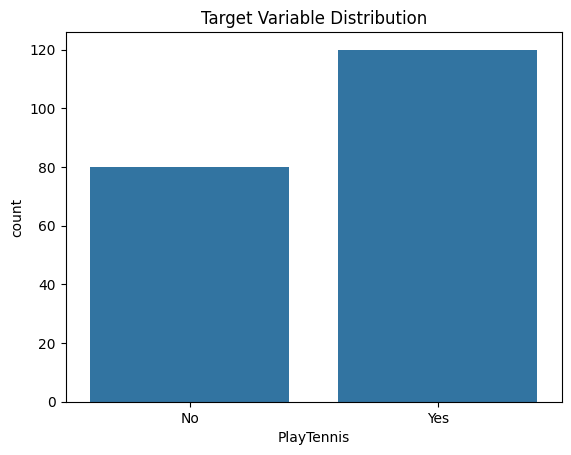

In [5]:
sns.countplot(x="PlayTennis", data=df)
plt.title("Target Variable Distribution")
plt.show()


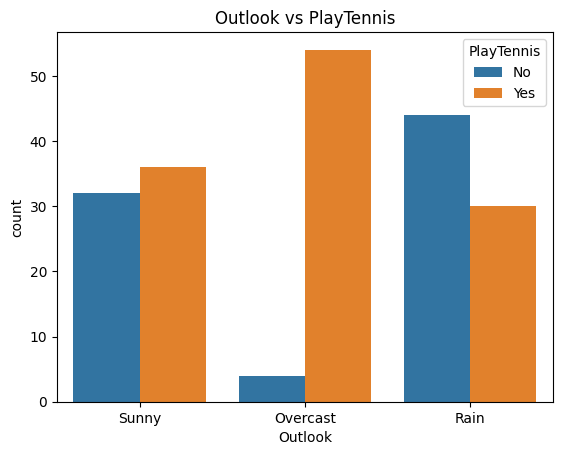

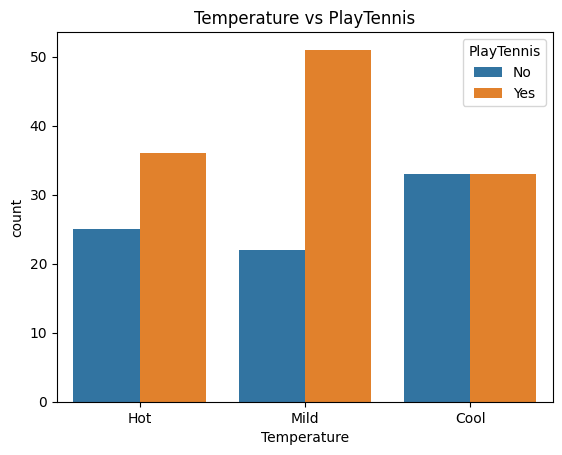

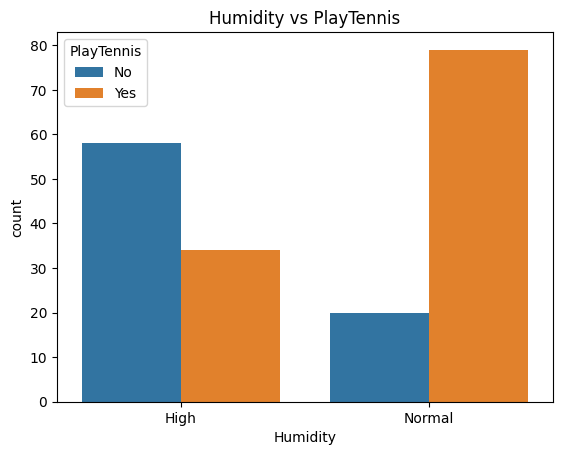

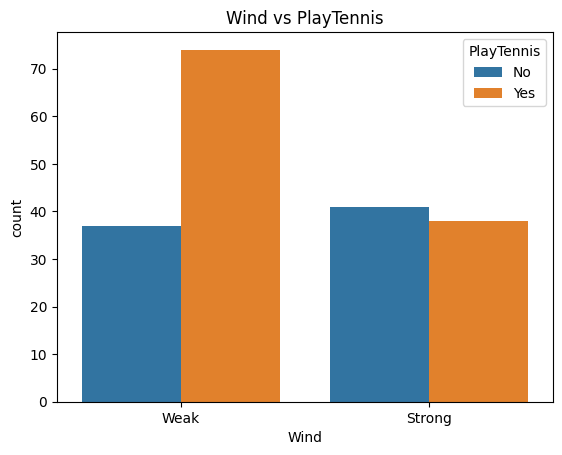

In [6]:
for col in cat_cols:
    if col != "PlayTennis":
        sns.countplot(x=col, hue="PlayTennis", data=df)
        plt.title(f"{col} vs PlayTennis")
        plt.show()


In [7]:
df["Wind"] = df["Wind"].fillna(df["Wind"].mode()[0])

df.isnull().sum()

Outlook        0
Temperature    0
Humidity       9
Wind           0
PlayTennis     0
dtype: int64

In [8]:
le = LabelEncoder()

for col in df.columns:
    df[col] = le.fit_transform(df[col])

df


,Outlook,Temperature,Humidity,Wind,PlayTennis
0,2,1,0,1,0
1,0,2,1,0,0
2,0,0,1,1,1
3,1,2,0,0,0
4,1,1,1,1,1
...,...,...,...,...,...
195,1,2,0,1,1
196,0,1,0,0,1
197,2,2,1,0,1
198,1,2,0,1,1


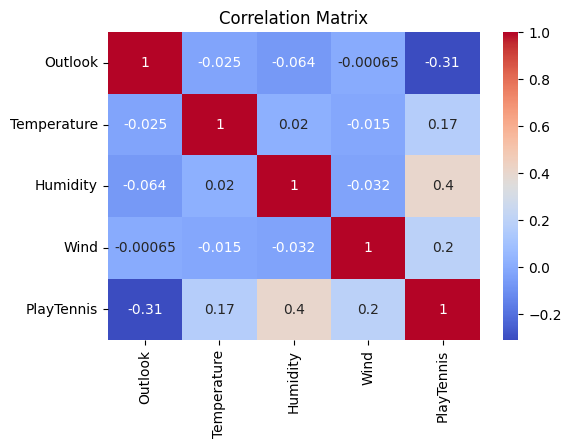

In [9]:
plt.figure(figsize=(6,4))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()


In [10]:
X = df.drop("PlayTennis", axis=1)
y = df["PlayTennis"]

X, y


(     Outlook  Temperature  Humidity  Wind
 0          2            1         0     1
 1          0            2         1     0
 2          0            0         1     1
 3          1            2         0     0
 4          1            1         1     1
 ..       ...          ...       ...   ...
 195        1            2         0     1
 196        0            1         0     0
 197        2            2         1     0
 198        1            2         0     1
 199        1            0         0     1
 
 [200 rows x 4 columns],
 0      0
 1      0
 2      1
 3      0
 4      1
       ..
 195    1
 196    1
 197    1
 198    1
 199    0
 Name: PlayTennis, Length: 200, dtype: int32)

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape, X_test.shape)


(160, 4) (40, 4)


In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, log_loss


In [13]:
models = {}
accuracies = {}
losses = {}
reports = {}
conf_matrices = {}


In [14]:
lr = LogisticRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)

models["Logistic Regression"] = lr
accuracies["Logistic Regression"] = accuracy_score(y_test, y_pred_lr)
losses["Logistic Regression"] = log_loss(y_test, y_prob_lr)
reports["Logistic Regression"] = classification_report(y_test, y_pred_lr)
conf_matrices["Logistic Regression"] = confusion_matrix(y_test, y_pred_lr)

accuracies["Logistic Regression"]


0.775

In [15]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)
y_prob_knn = knn.predict_proba(X_test)

models["KNN"] = knn
accuracies["KNN"] = accuracy_score(y_test, y_pred_knn)
losses["KNN"] = log_loss(y_test, y_prob_knn)
reports["KNN"] = classification_report(y_test, y_pred_knn)
conf_matrices["KNN"] = confusion_matrix(y_test, y_pred_knn)

accuracies["KNN"]


0.925

In [16]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)
y_prob_dt = dt.predict_proba(X_test)

models["Decision Tree"] = dt
accuracies["Decision Tree"] = accuracy_score(y_test, y_pred_dt)
losses["Decision Tree"] = log_loss(y_test, y_prob_dt)
reports["Decision Tree"] = classification_report(y_test, y_pred_dt)
conf_matrices["Decision Tree"] = confusion_matrix(y_test, y_pred_dt)

accuracies["Decision Tree"]


0.95

In [17]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)

models["Random Forest"] = rf
accuracies["Random Forest"] = accuracy_score(y_test, y_pred_rf)
losses["Random Forest"] = log_loss(y_test, y_prob_rf)
reports["Random Forest"] = classification_report(y_test, y_pred_rf)
conf_matrices["Random Forest"] = confusion_matrix(y_test, y_pred_rf)

accuracies["Random Forest"]


0.9

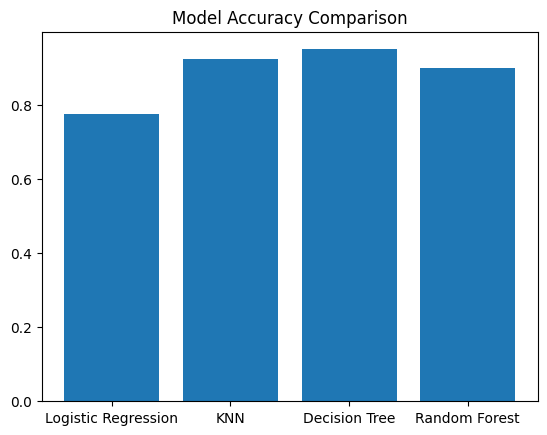

In [18]:
plt.figure()
plt.bar(accuracies.keys(), accuracies.values())
plt.title("Model Accuracy Comparison")
plt.show()


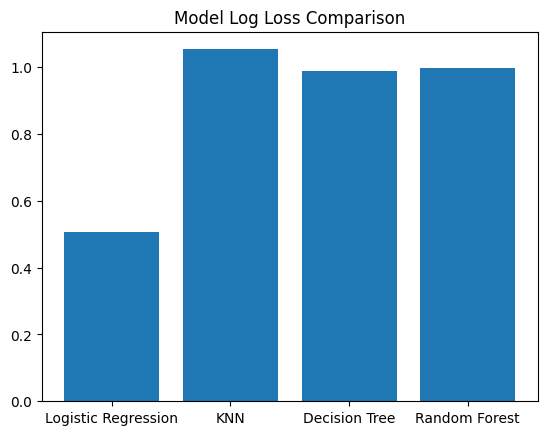

In [19]:
plt.figure()
plt.bar(losses.keys(), losses.values())
plt.title("Model Log Loss Comparison")
plt.show()


In [20]:
for name in reports:
    print(f"\n{name}")
    print(reports[name])



Logistic Regression
              precision    recall  f1-score   support

           0       0.71      0.75      0.73        16
           1       0.83      0.79      0.81        24

    accuracy                           0.78        40
   macro avg       0.77      0.77      0.77        40
weighted avg       0.78      0.78      0.78        40


KNN
              precision    recall  f1-score   support

           0       1.00      0.81      0.90        16
           1       0.89      1.00      0.94        24

    accuracy                           0.93        40
   macro avg       0.94      0.91      0.92        40
weighted avg       0.93      0.93      0.92        40


Decision Tree
              precision    recall  f1-score   support

           0       0.94      0.94      0.94        16
           1       0.96      0.96      0.96        24

    accuracy                           0.95        40
   macro avg       0.95      0.95      0.95        40
weighted avg       0.95      0.95

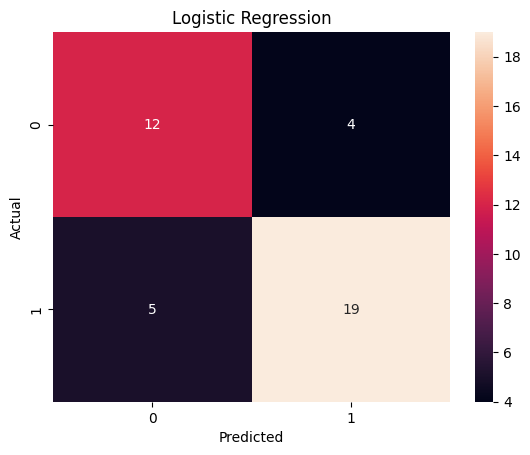

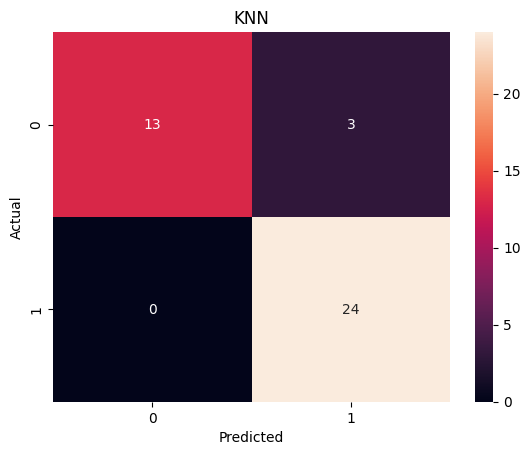

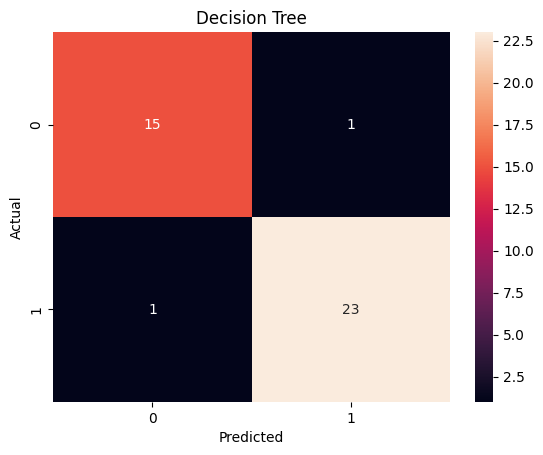

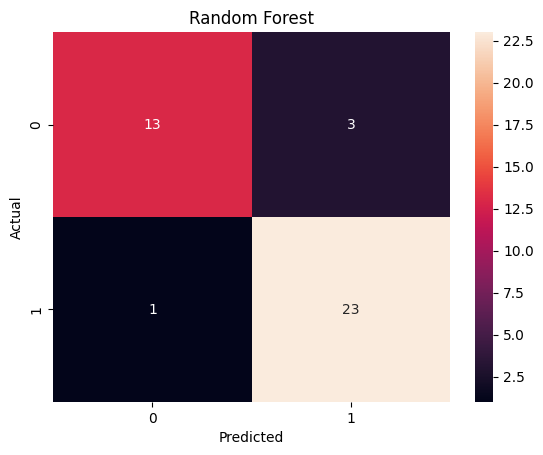

In [21]:
for name, matrix in conf_matrices.items():
    sns.heatmap(matrix, annot=True, fmt="d")
    plt.title(name)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


In [22]:
final_results = pd.DataFrame({
    "Model": accuracies.keys(),
    "Accuracy": accuracies.values(),
    "Loss": losses.values()
})

final_results


,Model,Accuracy,Loss
0,Logistic Regression,0.775,0.508044
1,KNN,0.925,1.053774
2,Decision Tree,0.950,0.988644
3,Random Forest,0.900,0.997800


In [23]:
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import classification_report
import pickle

# Assuming clf1, clf2, and clf3 are pre-defined base models
# and X_train, y_train, X_test, y_test are available in the workspace
ensemble_model = VotingClassifier(
    estimators=[('lr', lr), ('knn', knn), ('dt', dt),('rf',rf)],
    voting='soft'
)

ensemble_model.fit(X_train, y_train)
y_pred = ensemble_model.predict(X_test)

# Generate Classification Report
print("Classification Report:\n", classification_report(y_test, y_pred))

# Store the model as a .pkl file
model_filename = 'ensemble_model.pkl'
with open(model_filename, 'wb') as file:
    pickle.dump(ensemble_model, file)

print(f"Model successfully saved to {model_filename}")


Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.94      0.97        16
           1       0.96      1.00      0.98        24

    accuracy                           0.97        40
   macro avg       0.98      0.97      0.97        40
weighted avg       0.98      0.97      0.97        40

Model successfully saved to ensemble_model.pkl


In [25]:
"""
Inference Code for PlayTennis Classification
Add this code as a new cell at the end of your classification.ipynb notebook
"""

import pickle
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Step 1: Load the original data to recreate encoders
df_original = pd.read_csv("playtennis.csv")
df_original = pd.DataFrame(df_original)

# Step 2: Handle missing values (same as training)
df_original["Wind"] = df_original["Wind"].fillna(df_original["Wind"].mode()[0])

# Step 3: Create and fit label encoders for each feature column
feature_encoders = {}
feature_columns = ['Outlook', 'Temperature', 'Humidity', 'Wind']

for col in feature_columns:
    le = LabelEncoder()
    le.fit(df_original[col])
    feature_encoders[col] = le

# Also create encoder for target to decode predictions
target_encoder = LabelEncoder()
target_encoder.fit(df_original['PlayTennis'])

# Step 4: Load the saved model
with open('ensemble_model.pkl', 'rb') as file:
    loaded_model = pickle.load(file)

print("Model loaded successfully!")
print(f"Feature encodings:")
for col in feature_columns:
    print(f"  {col}: {dict(zip(feature_encoders[col].classes_, feature_encoders[col].transform(feature_encoders[col].classes_)))}")

# Step 5: Create inference function
def predict_play_tennis(outlook, temperature, humidity, wind):
    """
    Predict whether to play tennis given weather conditions
    
    Parameters:
    -----------
    outlook : str
        Weather outlook (e.g., 'Sunny', 'Overcast', 'Rain')
    temperature : str
        Temperature level (e.g., 'Hot', 'Mild', 'Cool')
    humidity : str
        Humidity level (e.g., 'High', 'Normal')
    wind : str
        Wind condition (e.g., 'Weak', 'Strong')
    
    Returns:
    --------
    str : Prediction ('Yes' or 'No')
    """
    try:
        # Encode the input features
        encoded_outlook = feature_encoders['Outlook'].transform([outlook])[0]
        encoded_temperature = feature_encoders['Temperature'].transform([temperature])[0]
        encoded_humidity = feature_encoders['Humidity'].transform([humidity])[0]
        encoded_wind = feature_encoders['Wind'].transform([wind])[0]
        
        # Create input array
        input_data = [[encoded_outlook, encoded_temperature, encoded_humidity, encoded_wind]]
        
        # Make prediction
        prediction_encoded = loaded_model.predict(input_data)[0]
        
        # Decode prediction
        prediction = target_encoder.inverse_transform([prediction_encoded])[0]
        
        return prediction
    except Exception as e:
        return f"Error: {str(e)}"

# Step 6: Example usage with the data provided by user
print("\n" + "="*50)
print("EXAMPLE PREDICTIONS")
print("="*50)

# Test with the example data from user's request
test_cases = [
    {'Outlook': 'Sunny', 'Temperature': 'Hot', 'Humidity': 'High', 'Wind': 'Weak'},
    {'Outlook': 'Overcast', 'Temperature': 'Mild', 'Humidity': 'Normal', 'Wind': 'Strong'},
    {'Outlook': 'Overcast', 'Temperature': 'Cool', 'Humidity': 'Normal', 'Wind': 'Weak'},  # Note: Wind was NaN in original, using 'Weak' as default
    {'Outlook': 'Rain', 'Temperature': 'Mild', 'Humidity': 'High', 'Wind': 'Strong'},
    {'Outlook': 'Rain', 'Temperature': 'Hot', 'Humidity': 'Normal', 'Wind': 'Weak'},
]

for i, test_case in enumerate(test_cases):
    result = predict_play_tennis(
        test_case['Outlook'],
        test_case['Temperature'],
        test_case['Humidity'],
        test_case['Wind']
    )
    print(f"\nTest Case {i+1}:")
    print(f"  Input: {test_case}")
    print(f"  Prediction: Play Tennis = {result}")


Model loaded successfully!
Feature encodings:
  Outlook: {'Overcast': 0, 'Rain': 1, 'Sunny': 2}
  Temperature: {'Cool': 0, 'Hot': 1, 'Mild': 2}
  Humidity: {'High': 0, 'Normal': 1, nan: 2}
  Wind: {'Strong': 0, 'Weak': 1}

EXAMPLE PREDICTIONS

Test Case 1:
  Input: {'Outlook': 'Sunny', 'Temperature': 'Hot', 'Humidity': 'High', 'Wind': 'Weak'}
  Prediction: Play Tennis = No

Test Case 2:
  Input: {'Outlook': 'Overcast', 'Temperature': 'Mild', 'Humidity': 'Normal', 'Wind': 'Strong'}
  Prediction: Play Tennis = Yes

Test Case 3:
  Input: {'Outlook': 'Overcast', 'Temperature': 'Cool', 'Humidity': 'Normal', 'Wind': 'Weak'}
  Prediction: Play Tennis = Yes

Test Case 4:
  Input: {'Outlook': 'Rain', 'Temperature': 'Mild', 'Humidity': 'High', 'Wind': 'Strong'}
  Prediction: Play Tennis = No

Test Case 5:
  Input: {'Outlook': 'Rain', 'Temperature': 'Hot', 'Humidity': 'Normal', 'Wind': 'Weak'}
  Prediction: Play Tennis = Yes


c:\Users\vikym\miniconda3\envs\gpu-env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
c:\Users\vikym\miniconda3\envs\gpu-env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(
c:\Users\vikym\miniconda3\envs\gpu-env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
c:\Users\vikym\miniconda3\envs\gpu-env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\vikym\miniconda3\envs\gpu-env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but L